In [1]:
import numpy as np              # load numerical module
import matplotlib.pyplot as plt # load plotting module
import astropy.io.fits as fits  # get FITS 
import pandas as pd             # get pandas 
import os                       #import os module
from mpl_toolkits.mplot3d import Axes3D
import gaussian as g
import radprof as R
import disk as d
import matplotlib.patches as pat

from itertools import product

In [2]:
#get data from a real Spitzer observation
lc_sample = np.loadtxt('2M1324_ch1lc.txt')
time      = lc_sample[ :,0 ]
photom    = lc_sample[ :,1 ]


In [3]:
#make function to convert modified julian dates to seconds differences
from datetime import datetime, timedelta

def mjd_to_secs(mjds):
    """Converts an array of Modified Julian Dates (MJD) to an array of Dts in secs;
    with thanks to Gemini for the core structure of MJD to datetime 
    conversion ;) """
    
    #define your 0th observation in normal Date/Time and go from there
    mjd_epoch = datetime(1858, 11, 17)  # MJD epoch
    date_time0 = mjd_epoch + timedelta(days=mjds[ 0 ])
    
    #make array where all your timestamps will go
    t_stamps  = np.zeros( len(mjds) )
    
    #we skip element 0 in the loop as by definition 0-0 will be 0
    #loop over the rest in reference to the 0 and get time difference in sec
    for i in range( 1, len( mjds )):
        date_time = mjd_epoch + timedelta(days=mjds[ i ])
        t_stamps[ i ] = (date_time - date_time0). total_seconds()
    
    return t_stamps

In [4]:
#call funct on all timestamps
update_time = mjd_to_secs(time)

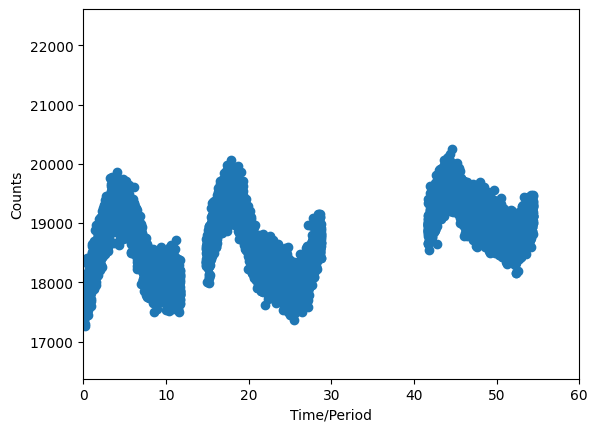

In [5]:
#make your plots
plt.scatter( update_time/3600, photom )
plt.xlim(0,60)
plt.ylabel('Counts')
dm = plt.xlabel('Time/Period')

In [6]:
lc_sample = np.loadtxt('2M2228_ch1lc.txt')
time      = lc_sample[ :,0 ]
photom    = lc_sample[ :,1 ]

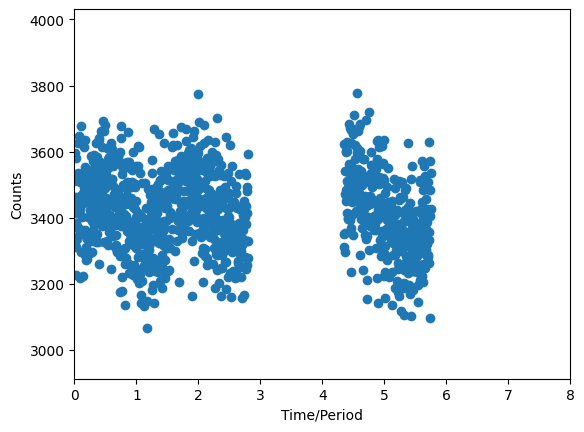

In [7]:
update_time = mjd_to_secs(time)
plt.scatter( update_time/3600, photom )
plt.xlim(0,8)
plt.ylabel('Counts')
dm = plt.xlabel('Time/Period')


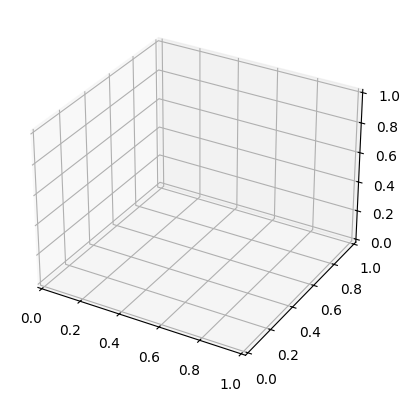

<Figure size 640x480 with 0 Axes>

In [8]:
f3D = 1
fig = plt.figure(f3D)
ax = fig.add_subplot(111, projection='3d')

f2D = 2
im = plt.figure(f2D)

# plotting defaults
cmap = 'summer_r'
rstride = 3
cstride = 3
kwargs = {"cmap":cmap, "rstride":rstride, "cstride":cstride}

# Utility function to put up a 2D and a 3D plot
def show2d3d(im2d, title, f2, f3, ax, x, y, kwargs):
#    figtitle = title.replace(" ", "-")

  # 2D figure
    plt.figure(f2)
    plt.clf()
    plt.imshow(im2d, origin="lower", interpolation='none')
    #if im2d.dtype != bool:  # colorbar breaks on bool due to deprecated math
    plt.colorbar()
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.show()
    
    # 3D figure ; w. fixed bug of apphotdemo.py
    
    
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
    ax.plot_surface(x, y, im2d.reshape(x.shape), 
                    cmap = 'YlGnBu')

    ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])

    ax.set_title(title)
    plt.show()



9.940291517383073
259765.6002494056


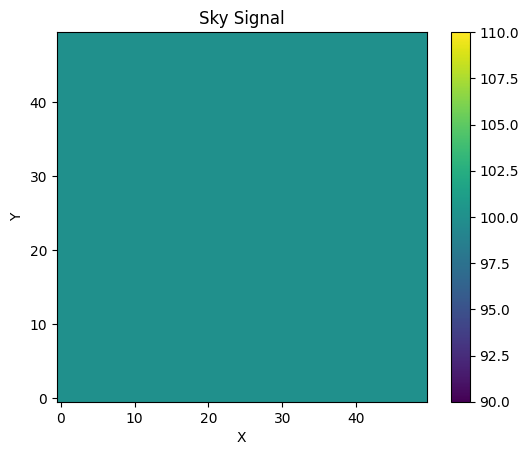

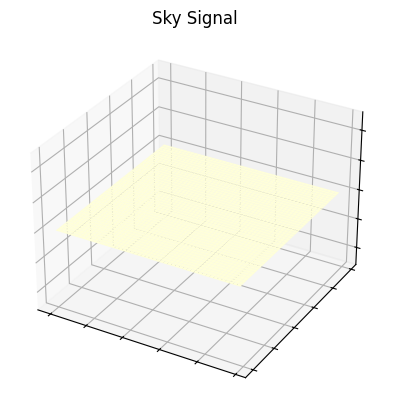

In [9]:
# make some fake data

# size of image
ny = 50
nx = 50

# star properties
cy       = 22.9
cx       = 21.2
seewidth = 3.
starlev  = 1e4 # somewhat noisy, peak comparable to sky

# sky property (only one)
skylev  = 1e2

# a bad pixel
by     = 33
bx     = 38
badlev = 300.

# coordinate index arrays, for doing math
coo = np.indices((ny, nx))
y, x = coo

# make the sky
skysignal = np.zeros((ny, nx)) + skylev
skynoise  = np.sqrt(skylev) * np.random.normal(size=(ny, nx))
skyim     = skysignal + skynoise
print(np.std(skynoise))

# make the star
starsignal = starlev * g.gaussian(coo, (seewidth, seewidth), (cy, cx)) + skylev
starnoise  = np.sqrt(starsignal) * np.random.normal(size=(ny, nx))
starim     = starsignal + starnoise
print(np.sum(starim))

# add the bad pixel, make it as big as the whole star
starim[by, bx] = badlev

show2d3d(skysignal,  "Sky Signal",  f2D, f3D, ax, x, y, kwargs)


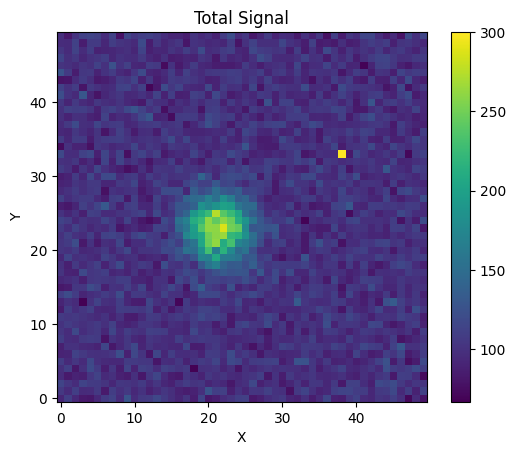

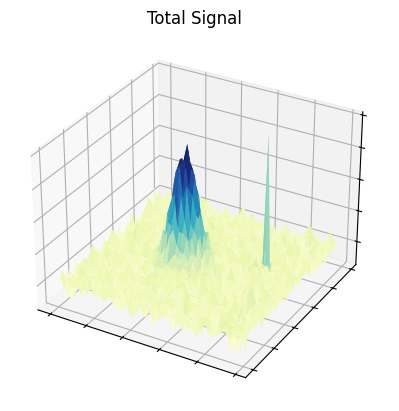

In [10]:
show2d3d(starim,  "Total Signal",  f2D, f3D, ax, x, y, kwargs)


### Choosing the Star Aperture and Sky Annulus: 
- We want to estimate the flux of the star
- Some background remains (even with sky image subtraction)
- How far out from star center to count?
    - Establish center accurately (see previous lecture)
    - Look at radial profile of star
    - Want all of starlight, but minimal sky noise
    - How far out to count? (radial profile)

- The optimal aperture size for best S/N varies with S/N (see below and next ICA)
- Must do same apertures for all stars to avoid systematic error
    - Often, we **compare photometry done with different apertures**

    - Check your aperture size!
- Establish $\sigma$ using bright star (why bright?)
- Use 'gaussian.fitgaussian()' or just do FWHM and convert


- Count DN within 3-4$\sigma$ from center for star
- Count DN in sky annulus farther out
- Want many more sky pixels than aperture pixels for better S/N


## Aperture Photometry Formula
1. Define an aperture
2. center it around the star
3. Sum the flux in it
4. Count the pixels in it

5. Define an annulus away from the star but centered on it
6. Sum the flux in it
7. Count the pixels in it
    - Do not count bad pixels in sky region (why must we fix and count for star?)
8. extract the values of all the pixels within the annulus, sum them, and divide by the total number of pixels within the annulus $\rightarrow$ average per pixel background for your image
    - For a good statistical determination of the background level, the total # of pixels in annulus should be $\sim3\times$ number contained within source aperture
    
    


|       | Light   (DN)  | Area  (pix$^2$) |              |
| :---- | :-----------: | :-------------: | ----------:  |
| Star  | $F_{*}$       | $N_{*}$         | must fix     |
| Sky   | $F_{\rm sky}$ | $N_{\rm sky}$   | don\'t count |

- Aperture photometry equation:
\begin{equation}
  F_{*,{\rm cal}} =   F_{*,{\rm raw}}
          - N_{*}
                    \frac{F_{\rm sky}}
                         {N_{\rm sky}} = F_{*,{\rm raw}} - N_{*} \bar{F_{sky}}
\end{equation}
- Or, subtract mean sky from image, then sum aperture (same thing)



## Apertures in Python
- Make and Multiply Masks: 3M method
    1. Cut out area with star to 10$\sigma$ or more
    2. Find PSF center
    3. Make mask of aperture and annulus, same size as cut-out
    4. Multiply by image
    5. Sum masked images for fluxes, sum masks for areas (numbers of pixels)<br><br>
    6. To make annulus mask, make 2 concentric disk masks and subtract
    7. Multiply annulus mask by cut-out of image bad pixel mask to avoid counting bad pixels
    8. Mask other stars in annulus (crowded-field photometry)
    9. Ensure no other stars in circle!
        - NOTE: Crucial to count pixels when finding the area, do not use $\pi r^{2}$



  wy          wx            cy           cx           height
[3.01394373 2.96004894] [22.9451941  21.27709808] 175.5584138382812
[0.00458605 0.0045041  0.00458605 0.0045041  0.26712738]


Text(0.5, 1.0, 'Radial Profile')

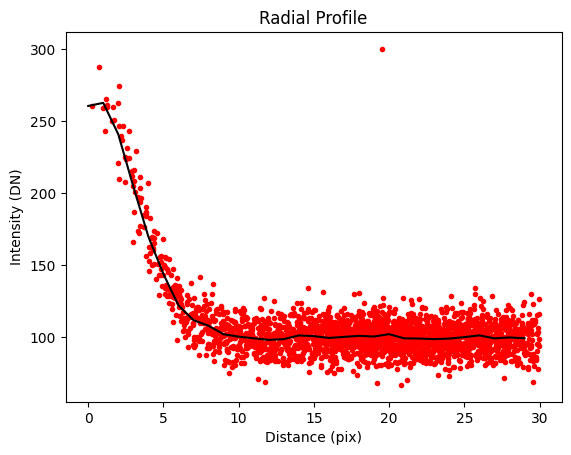

In [13]:
# Identify center using Gaussian centering
# Note that we subtract the median (approximate sky) to make Gaussian
# wings go to zero.  We'll do a better job with the sky once we have a
# better center.
guess = ((seewidth, seewidth), (cy, cx), starim.max())
(fw, fc, fh, fe) = g.fitgaussian(starim - np.median(starim), guess=guess)
print("  wy          wx            cy           cx           height")
print(fw, fc, fh)
print(fe)

# look at radial profile
(bins, rp, sr, sim) = R.radprof(starim, fc[0], fc[1])
frp = 3
plt.figure(frp)
plt.clf()
pbin = 30
incl = np.where(sr <= pbin)[0]
plt.plot(sr[incl], sim[incl], '.r')
plt.plot(bins[0:pbin], rp[0:pbin], '-k')
plt.xlabel('Distance (pix)')
plt.ylabel('Intensity (DN)')
plt.title('Radial Profile')
#plt.savefig('Radial_Profile.png')


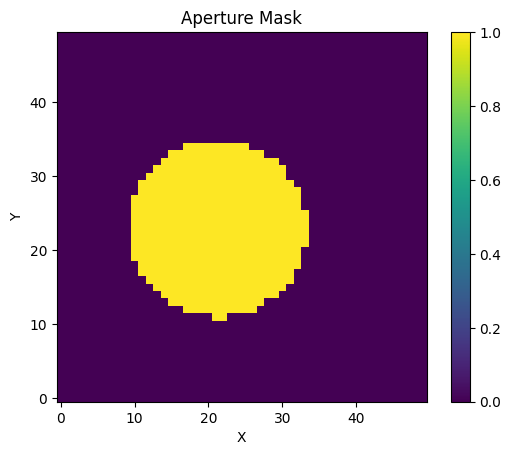

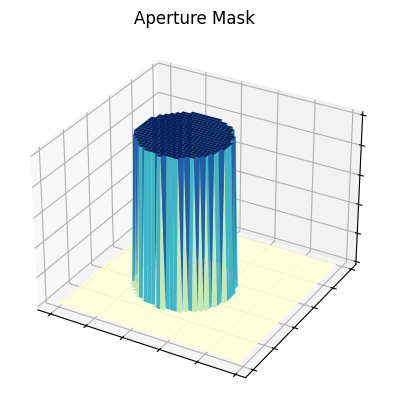

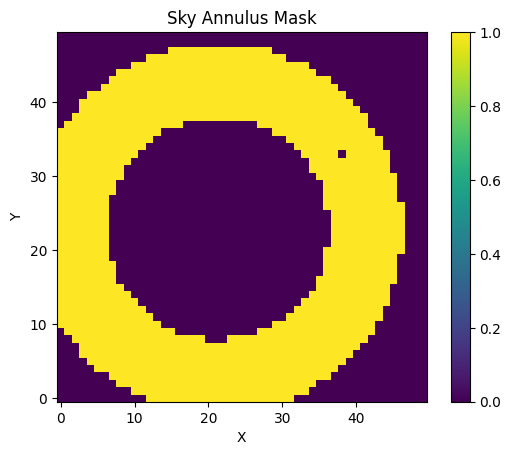

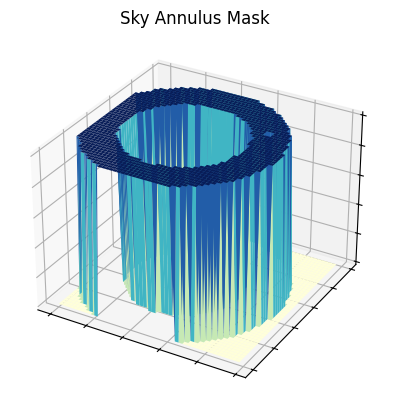

In [14]:
# Set aperture, sky inner and outer radii
aprad  = 12.
skyin  = 15.
skyout = 25.

# make a mask of bad pixels
badpix  = np.ones((ny, nx), dtype=np.bool)
badpix[by, bx] = False

# Make masks
apmask  =   d.disk(aprad,  fc, starim.shape)
skymask =   d.disk(skyout, fc, starim.shape) \
          ^ d.disk(skyin,  fc, starim.shape)

apmask  *= badpix
skymask *= badpix

show2d3d( apmask, "Aperture Mask",     f2D, f3D, ax, x, y, kwargs)
show2d3d(skymask, "Sky Annulus Mask",  f2D, f3D, ax, x, y, kwargs)
# NOTE: If bad pixel appears in the aperture, must interpolate or toss frame.
# No problem if it appears in the sky, we just don't count it.


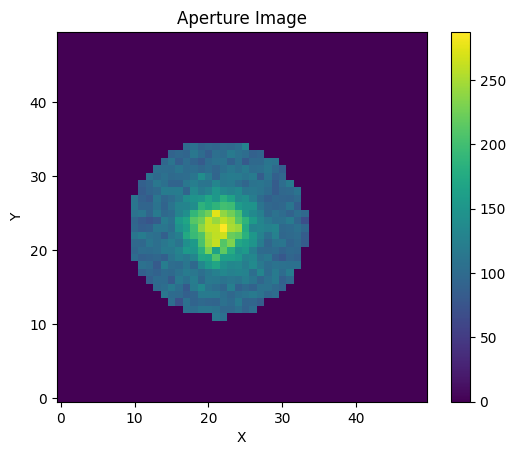

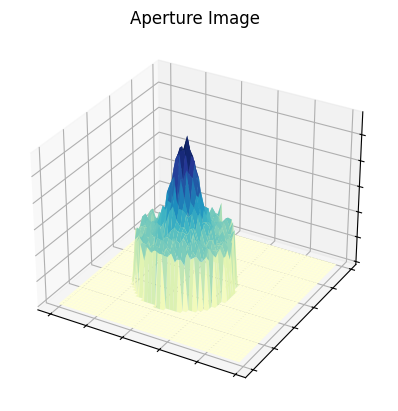

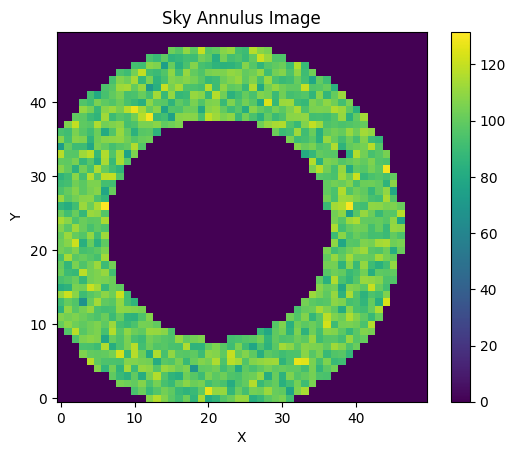

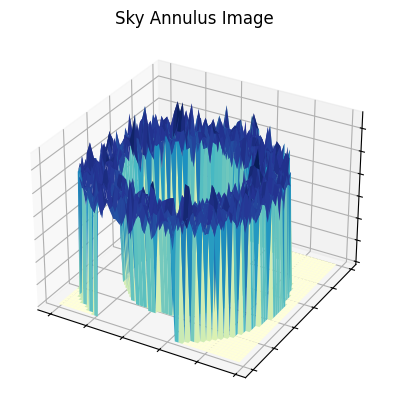

In [19]:
# Apply masks
apim =  apmask * starim # Star aperture mask times star image
anim = skymask * starim # Sky annulus mask times star image

show2d3d(apim, "Aperture Image",     f2D, f3D, ax, x, y, kwargs)
show2d3d(anim, "Sky Annulus Image",  f2D, f3D, ax, x, y, kwargs)



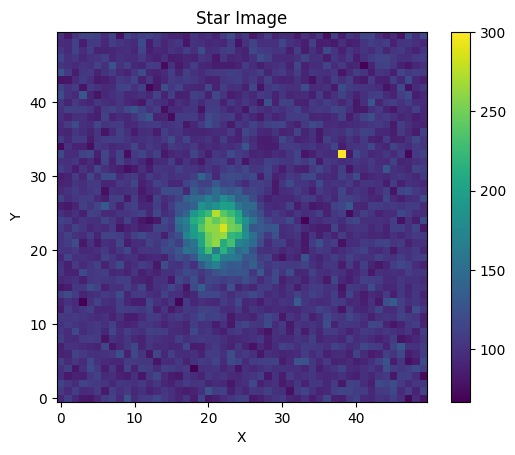

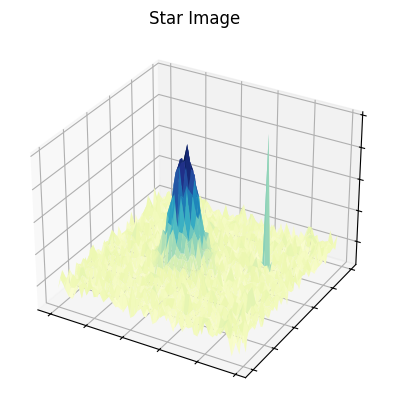

In [17]:
# Apertures on image
show2d3d(starim,     "Star Image",  f2D, f3D, ax, x, y, kwargs)


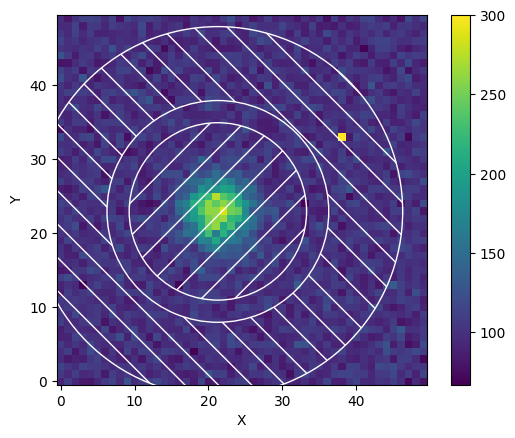

In [18]:
plt.figure(f2D)
plt.imshow(starim, origin="lower", interpolation='none')
    #if im2d.dtype != bool:  # colorbar breaks on bool due to deprecated math
plt.colorbar()
plt.xlabel("X")
plt.ylabel("Y")
    
ax2 = plt.gca()
appat = pat.Circle(fc[::-1], aprad, fc="none", hatch='/', color="white")
ax2.add_artist(appat)
skypat = pat.Wedge(fc[::-1], skyout, 0, 360,
                   fc="none", width=skyout-skyin, hatch='\\', color="white")
ax2.add_artist(skypat)
#plt.savefig("Star-Image-with-Photometry.png")


In [20]:
# Calculate fluxes and uncertainties
# NOTE: COUNT pixels, do not use pi*r**2 !
Nstar = np.sum(apmask)      # Count pixels in the aperturn
Nsky  = np.sum(skymask)     # Count pixels in the annulus
apraw = np.sum(apim)        # Sum the pixels in the aperture
anavg = np.sum(anim) / Nsky # Average the good pixels in the annulus

starphot = apraw - Nstar * anavg    # The Aperture Photometry Formula
skystd   = np.std(starim[skymask])  # Works since mask is True/False
starunc  = (starphot + Nstar * skystd**2)**0.5 # Add variances, take sqrt

print("Number of aperture pixels: "+str(Nstar))
print("Number of sky      pixels: "+str(Nsky))
print("Raw aperture counts:       "+str(apraw))
print("Mean sky:                  "+str(anavg))
print("Sky sigma:                 "+str(skystd))
print("Corrected aperture counts: "+str(starphot))
print("Uncertainty counts:        "+str(starunc))

# Is it within 1sigma?
# Are there more sky pixels than aperture pixels?
# What could limit aperture size?
# What could limit annulus size?


Number of aperture pixels: 452
Number of sky      pixels: 1187
Raw aperture counts:       55168.478703105255
Mean sky:                  99.8149414978398
Sky sigma:                 9.630720214775145
Corrected aperture counts: 10052.125146081664
Uncertainty counts:        227.98130191896792


## S/N Behaves Differently for Bright and Dim Stars
- Bright object overwhelms BG, not much contribution to noise compared to star flux

| PSF            | SNR             |
| ---------------------- | ---------------------- |
| ![s1](1brightpsf.jpg) | ![s1](2brightsn.jpg) |



- Dim star (not much above background)
| PSF            | SNR             |
| ---------------------- | ---------------------- |
| ![s1](3dimpsf.jpg) | ![s1](4dimsn.jpg) |



 - As aperture gets bigger, S/N drops.  Why?




## Advanced 1: Aperture Correction
- If you have *good* centering, a consistent PSF, and a good PSF model (e.g., spacecraft data)...
    - You can take a smaller aperture, losing some star flux
    - This reduces $N_\mathrm{sky}$, and thus read noise

    - Do photometry on the model PSF with the same aperture
    - This finds the fraction of captured flux
    - Divide measured photometry by fraction of captured flux
    - This is tricky; do some tests to see if it improves things
    - E.g., move aperture around on PSF with expected centering accuracy to see if variation exceeds benefit from small aperture

## Advanced 2: Interpolated Aperture Photometry
- For underresolved images, pixelation creates noise comparable to read noise or worse
    - Use either nearest-neighbor or bilinear interpolation (they conserve flux)
    - Interpolate each pixel to a 5{$\times$}5 grid (test to see if more improves things)
    - Do photometry on that
    - Image size will jump by 25{$\times$}, so cut out a small area, first!


### Here we will use astropy and [photutils](https://photutils.readthedocs.io/en/stable/api/photutils.centroids.centroid_com.html) and two different [centroid](https://photutils.readthedocs.io/en/stable/centroids.html) methods to fit the star

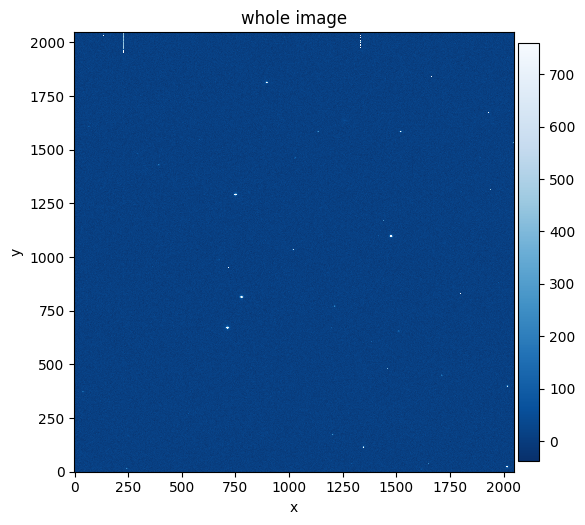

In [21]:
#!/usr/bin/env python3
# Centroids, rho array, sky estimates
# October 26, 2022
# by Yan Fernandez for AST 4762/5765.
#updates to python coding TK
"""Check out centroids, the rho array, and estimating the sky contribution"""
#----------------------------------------------------------------------------
#This program covers three topics.
# One is a demo of centroiding.
# Next is a reminder about the rho array
# (since we actually made one in a previous program)
# Third is estimating the sky background.
#----------------------------------------------------------------------------
#import numpy as np
#from numpy import polynomial
#import math
#import matplotlib.pyplot as plt
#from scipy import special
#from scipy import stats
#from scipy.stats import chi2
#import sys
#----for reading in and writing out FITS files:
#import astropy
#from astropy import io
#from astropy.io import fits
#----for doing some fitting
from astropy import modeling
#----for doing some centroiding
#import photutils
from photutils.centroids import centroid_com, centroid_2dg
#----for being able to copy arrays.
import copy
#----------------------------------------------------------------------------
#This part is same as before:
#----------------------------------------------------------------------------
#First let's get an image that we'll play around with.
#It's a clean, science-quality image, so we don't need to
#do the de-biasing and flat-fielding.
#For Yan's reference, this file is nt2raw/nt2.034cl.fits
fil = 'examplecleanimage2.fits'
#with fits.open(fil) as img:
#    cleanimg = img[0].data
cleanimg = fits.getdata( fil )
#trim off the overscan, we don't need it.
cleanimg = cleanimg[0:2048,19:2067]
#check for any non-finite pixels, and replace them.
#whinf = np.where( np.isfinite(cleanimg) != 1 )
#cleanimg[whinf] = np.median(cleanimg)
cleanimg = np.where( np.isfinite(cleanimg) != 1, np.median(cleanimg), cleanimg )


#show the image
qm = np.median(cleanimg)
qs = np.std(cleanimg)
plt.figure(figsize = (6,6) )
im1 = plt.imshow(cleanimg, interpolation='none', origin='lower', 
           vmin=qm-0.2*qs, vmax=qm+3.0*qs, cmap='Blues_r')
plt.colorbar(im1 ,fraction=0.045, pad=0.01)
plt.xlabel("x")
plt.ylabel("y")
dm = plt.title("whole image")
#plt.show()
#input(":")


size : _com xc yc _2dg xc yc
  3 :  752.08 , 1291.05  752.25 , 1291.19


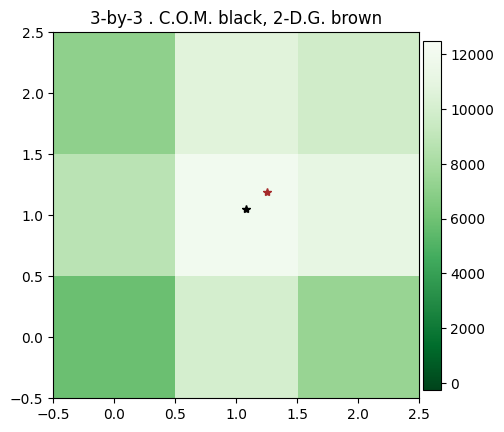

  5 :  752.09 , 1291.12  752.18 , 1291.15


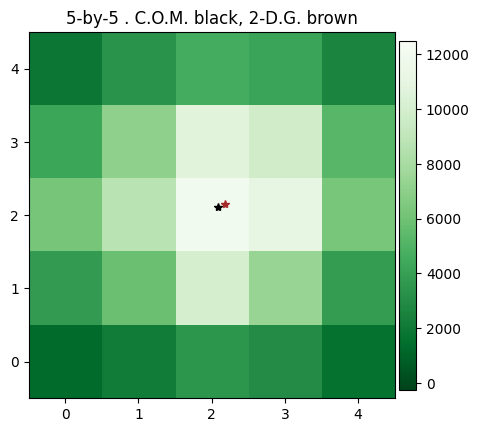

  7 :  752.07 , 1291.13  752.14 , 1291.15


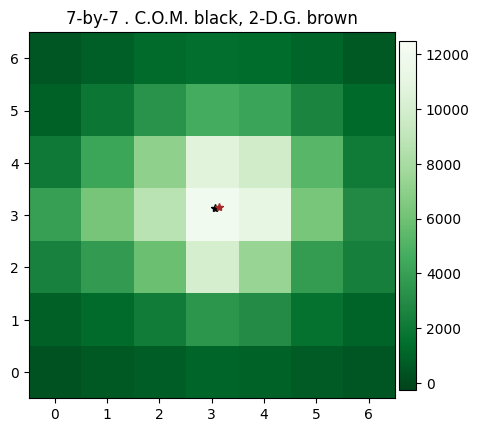

  9 :  752.05 , 1291.13  752.13 , 1291.15


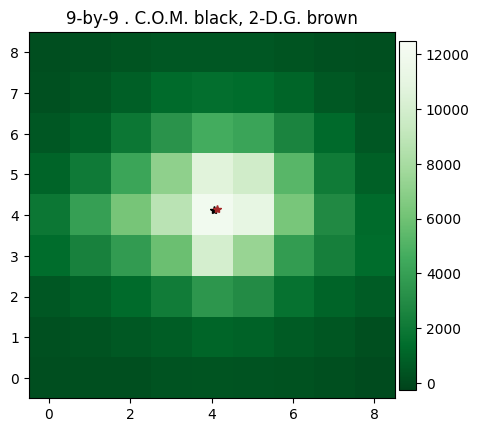

 11 :  752.05 , 1291.13  752.13 , 1291.15


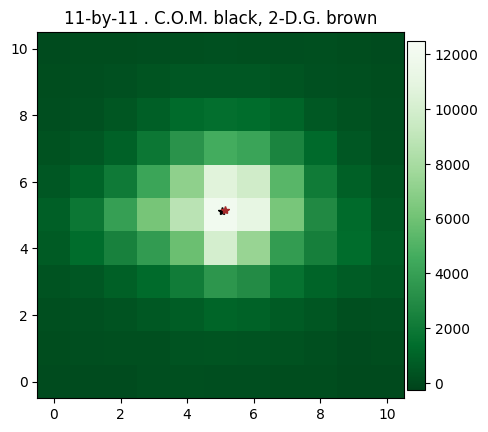

In [22]:
#----------------------------------------------------------------------------
#----------------------------------------------------------------------------
#
#Part 1
#
#
# now work on centroids. work on a star that's in the upper-left area
# of the image. Recall that star center is near y=1291, x=752.
# We'll try both methods of centroiding -- the center of mass
# method and the 2-d gaussian fitting method.
# We'll try several subarrays, just to see how the calculation changes.


#star location
xref = 752
yref = 1291
qm = np.median( cleanimg )
qs = np.std( cleanimg )
print("size : _com xc yc _2dg xc yc")

for i in range(5):
    offs = i + 1
    #make the tiny subarray.
    sub = cleanimg[ yref-offs : yref+offs+1, xref-offs : xref+offs+1 ]
    
    #calculate the centroids using two methods from astropy
    xcen1, ycen1 = centroid_com( sub )
    xcen2, ycen2 = centroid_2dg( sub )
    print("%3d : %7.2f , %7.2f %7.2f , %7.2f" % 
          (2*offs+1, xcen1+xref-offs, ycen1+yref-offs, 
           xcen2+xref-offs, ycen2+yref-offs))

    #show the subarray.
    plt.figure( figsize = (5,5 ) )
    im3 = plt.imshow(sub, interpolation='none', origin='lower', 
               cmap='Greens_r', vmin=qm-1.0*qs, vmax=qm+50.0*qs)
    plt.title(str(2*offs+1)+"-by-"+str(2*offs+1)+" . C.O.M. black, 2-D.G. brown")
    plt.plot( xcen1 , ycen1,'*',color='Black')
    plt.plot( xcen2 , ycen2,'*',color='Brown')
    
    plt.colorbar( im3 ,fraction=0.045, pad=0.01 )
    
    dm = plt.show()
    
    #input(":")
#Let's use the c.o.m. method as the one we'll save, going forward.
#The output is the centroid in the given frame --- so to put it
#in terms of global CCD coordinates, we need to add the offset
#We'll just pick the option where i==4; there's no strong reason
# for it other than the test above seems to give consistent answers
# and so this choice is as good as any. We do choose the COM answer,
# not the 2dg answer. Yan just really preferes the COM answer because
# you can never be totally sure that a 2-D Gaussian is going to be
# an appropriate shape.

    if (i == 4):
        xcntrduse = xcen1 + xref-offs
        ycntrduse = ycen1 + yref-offs




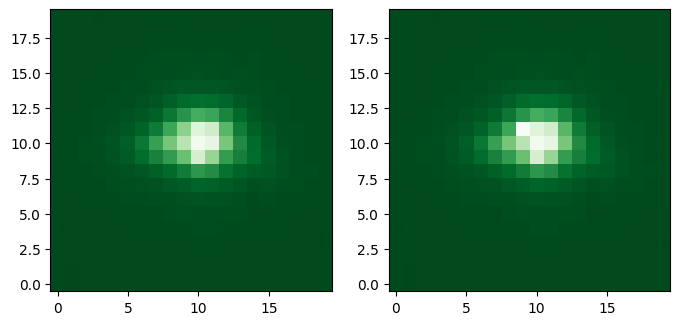

In [23]:
#Just for fun - let's by hand change the value of one of the
#pixels near the center, and recalculate the centroids.
#This is not something you'd normally do, alter pixel values,
#but this will just demo how the centroid depends on the
#distribution of light.
#

#Note that the 2-d gaussian centroid method will complain
#here because the new modified star isn't really close to
#being a gaussian any more....
cleanimg2 = copy.copy(cleanimg)

#change the one pixel but multiplying by 15. It's just a choice.
cleanimg2[yref+1, xref-1] = cleanimg2[yref-1, xref-1] * 15.0

#visualize what you did first:
qm2 = np.median( cleanimg )
qs2 = np.std( cleanimg )

fig,ax = plt.subplots( 1,2, figsize = (8,4) )
ax[0].imshow( cleanimg[yref-10:yref+10, xref-10:xref+10], 
             vmin=qm-1.0*qs, vmax=qm+50.0*qs,  cmap='Greens_r' , origin='lower')
dm = ax[1].imshow( cleanimg2[yref-10:yref+10, xref-10:xref+10], 
             vmin=qm2-1.0*qs2, vmax=qm2+50.0*qs2, cmap='Greens_r' , origin='lower')


size : _com xc yc _2dg xc yc
  3 :  751.55 , 1291.52  750.98 , 1292.00
  5 :  751.69 , 1291.44  751.16 , 1291.85
  7 :  751.73 , 1291.41  751.16 , 1291.85
  9 :  751.74 , 1291.39  751.16 , 1291.85
 11 :  751.75 , 1291.38  751.16 , 1291.85


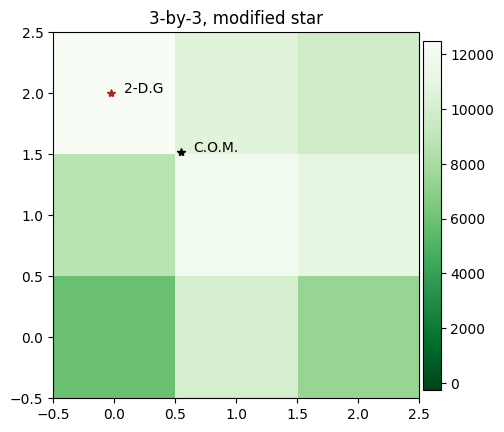

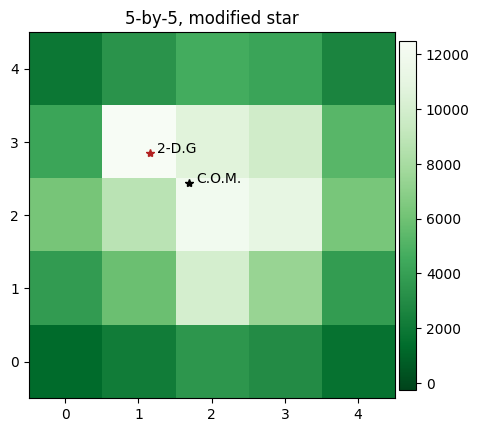

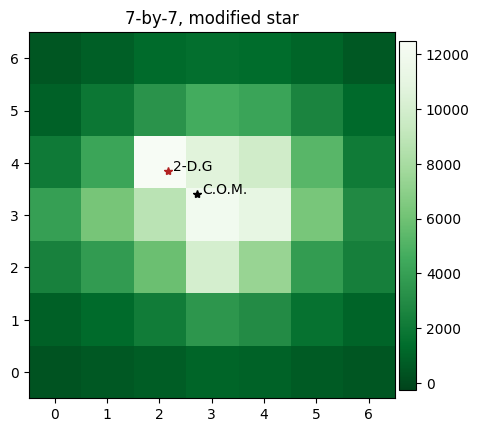

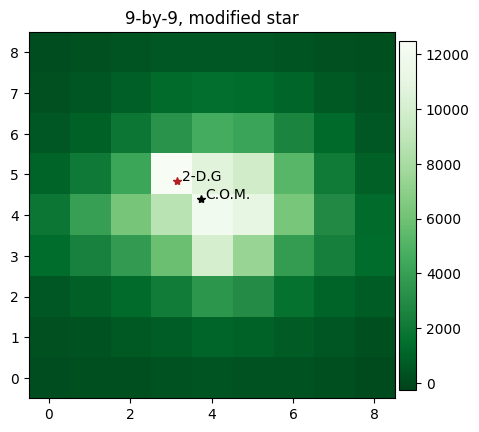

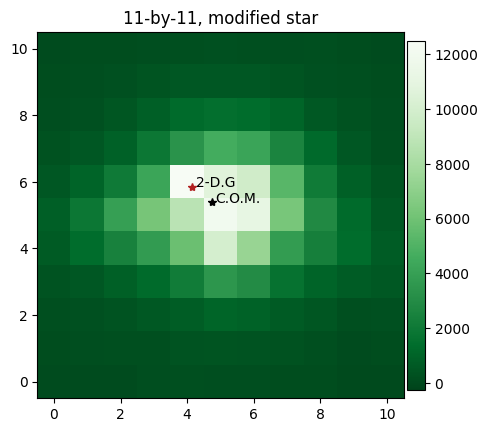

In [24]:
print("size : _com xc yc _2dg xc yc")
for i in range(5):
    offs = i + 1
    sub = cleanimg2[yref-offs:yref+offs+1,xref-offs:xref+offs+1]
    xcen1, ycen1 = centroid_com(sub)
    xcen2, ycen2 = centroid_2dg(sub)

    print("%3d : %7.2f , %7.2f %7.2f , %7.2f" % 
          (2*offs+1, xcen1+xref-offs, ycen1+yref-offs, 
           xcen2+xref-offs, ycen2+yref-offs))

    plt.figure( figsize = (5,5) )
    im4 = plt.imshow(sub, interpolation='none', origin='lower', 
                     cmap='Greens_r', vmin=qm-1.0*qs, vmax=qm+50.0*qs)
    plt.title( str(2*offs+1)+"-by-"+str(2*offs+1) + ', modified star')

    plt.plot(xcen1, ycen1 ,'*',color='Black')
    plt.text( xcen1+.1, ycen1, 'C.O.M.' )
    plt.plot( xcen2, ycen2,'*',color='Firebrick')
    plt.text( xcen2+.1, ycen2, '2-D.G' )
    dm = plt.colorbar( im4 ,fraction=0.045, pad=0.01  )
#plt.show()
#input(":")


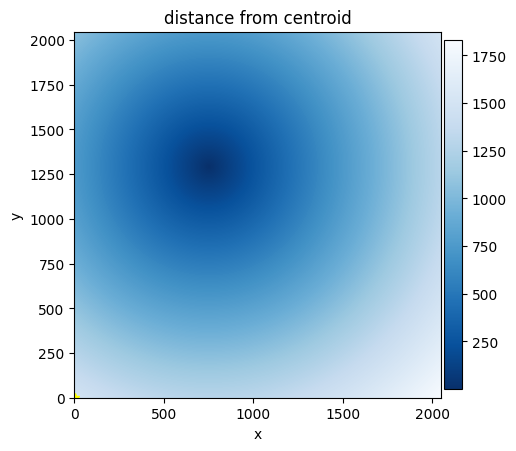

In [25]:
#----------------------------------------------------------------------------
#----------------------------------------------------------------------------
#
#Part 2
#
#
#now make a "rho" array. i.e. an array whose pixel value is the
#distance away from the centroid.
#We did this in an earlier program, but this time instead of
# basing it on the distance from the center of the brightest pixel,
# we'll have it give us the distance from the centroid instead!
#Going forward, this is probably the way you'll actually want to use it.
#It's easy! Just two lines.
sy, sx = np.indices( cleanimg.shape )
rho = np.sqrt( (sx - xcntrduse)**2 + (sy - ycntrduse)**2 )
#show the array
plt.figure( figsize = (5,5 ))
im5 = plt.imshow(rho, interpolation='none', origin='lower', 
           cmap='Blues_r')
plt.xlabel("x")
plt.ylabel("y")
plt.title("distance from centroid")
plt.plot(xcen1, ycen1,'*',color='Yellow')
dm = plt.colorbar( im5 ,fraction=0.045, pad=0.01  )
#plt.show()
#input(":")


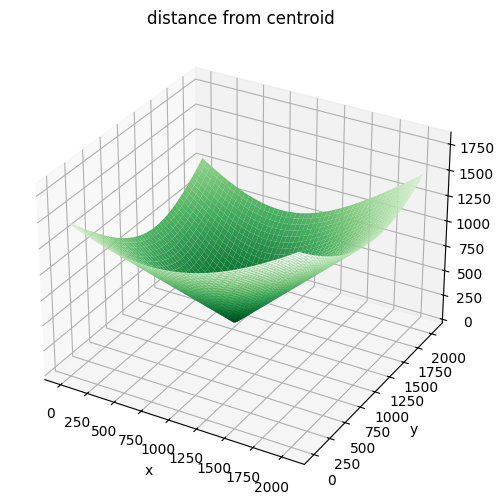

In [26]:
#surface plot
#%matplotlib                           
fig = plt.figure( figsize=(12,6) ) 
ax = fig.add_subplot(projection="3d")
ax.plot_surface(sx, sy, rho, cmap='Greens_r')
plt.xlabel("x")
plt.ylabel("y")
dm = plt.title("distance from centroid")
#plt.show()
#input(":")


In [27]:
#%matplotlib inline

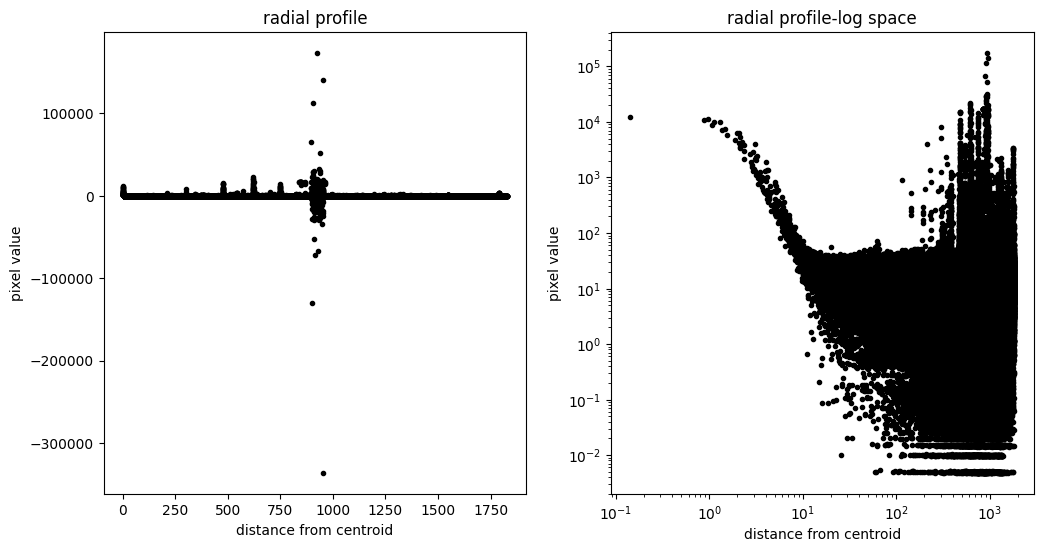

In [28]:
#Show the radial profile, in linear space.
#Good idea to zoom in to the left part of the graph to
#see the meaty part of the profile.

fig,ax = plt.subplots( 1,2, figsize = (12, 6) )
ax[0].plot(rho, cleanimg, '.', color='Black')
ax[0].set_xlabel("distance from centroid")
ax[0].set_ylabel("pixel value")
ax[0].set_title("radial profile")

#now plot in log space.

ax[1].loglog(rho, cleanimg, '.', color='Black')
ax[1].set_xlabel("distance from centroid")
ax[1].set_ylabel("pixel value")
dm = ax[1].set_title("radial profile-log space")


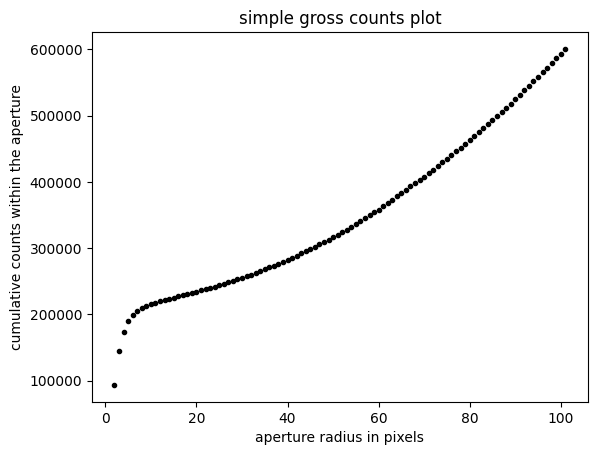

In [29]:
#----------------------------------------------------------------------------
#----------------------------------------------------------------------------
#
#Part 3
#
#
#Estimate some sky brightnesses, and show how gross counts and
#net counts behave.
#First, calculate gross counts as a function of aperture radius
nap = 100 # number of apertures to try
startap = 2.0 # starting aperture radius
aps = np.linspace( startap, startap+nap-1, nap ) # make all the aperture radii.

grosscnts = np.zeros(nap) #save gross counts here.
nelinap = np.zeros(nap) #also keep the # of pixels in each aperture.
#nelinap = number of elements in the aperture.
for i in range(nap):
    incl = np.where( rho <= aps[i] )
    nelinap[i] = incl[0].size
    grosscnts[i] = np.sum(cleanimg[incl])
#make a plot of the gross counts. note how the gross counts
#keeps rising as aperture gets bigger and bigger -- that's the sky counts!
#plt.figure()
plt.plot(aps, grosscnts, '.', color='black')
plt.xlabel("aperture radius in pixels")
plt.ylabel("cumulative counts within the aperture")
dm = plt.title("simple gross counts plot")
#plt.show()
#input(":")


sky estimates:
[24.90156174 16.72254562 13.5770874  12.97972584 12.42311001 12.28081703
 11.85486794 11.24190331]


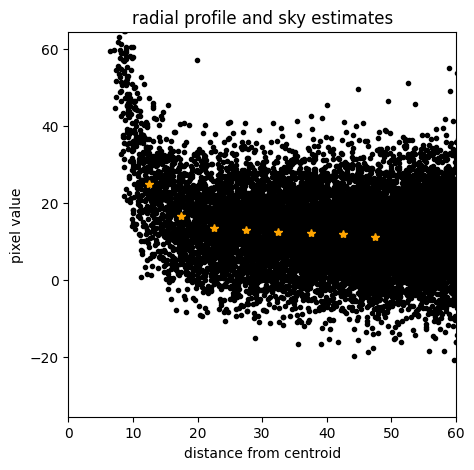

In [30]:
#Now estimate the sky in various rings around the star.
#let's try several rings and see how much variation there is.
#let's make the rings 5 pixels wide.
skyinnerbound = np.arange( 10, 46, 5 ) #asarray([10., 15., 20., 25., 30., 35., 40., 45.])
skyouterbound = skyinnerbound + 5.0
skyringmiddle = (skyinnerbound + skyouterbound)/2.
nsb = len( skyinnerbound )
skyestims = np.zeros(nsb)

for i in range(nsb):
    thisring = np.where( (rho >= skyinnerbound[i]) & 
                        (rho <= skyouterbound[i]) )
    skyestims[i] = np.median(cleanimg[thisring])

#plot the sky estimates on the radial profile.
#Note that even though it may not seem like it to the eye when
#you look at the image of the star, there is still some flux from
#the star way out at 10, 15, maybe even 20 pixels away from the star!
#So you have to be really careful when assessing the sky flux.
plt.figure( figsize = (5,5) )
plt.plot(rho, cleanimg, '.', color='Black')
plt.xlabel("distance from centroid")
plt.ylabel("pixel value")
plt.title("radial profile and sky estimates")
plt.xlim(0,np.max(skyouterbound)+10)
plt.ylim(np.mean(skyestims)-50., np.mean(skyestims)+50.)
dm= plt.plot(skyringmiddle, skyestims, '*', color='orange')
#plt.show()
print("sky estimates:")
print(skyestims)


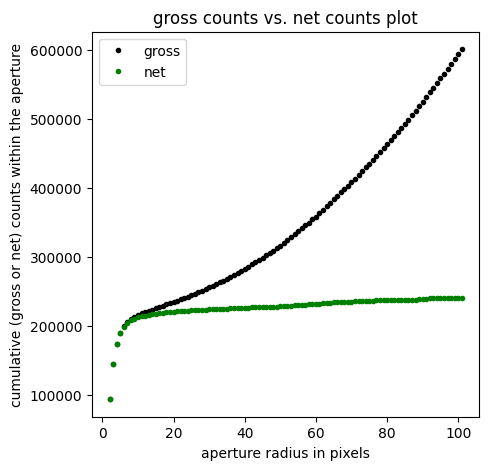

In [31]:
#input(":")
#OK let's use the last one as our estimate of the real sky brightness
#Let's just pick the last one we measured. In the real world, you
#would do a more careful assessment of what the best choice would be.
skybrt = skyestims[nsb-1]
netcnts = grosscnts - nelinap * skybrt
plt.figure( figsize= (5,5) )
plt.plot(aps, grosscnts, '.', color='black', label='gross')
plt.plot(aps, netcnts, '.', color='green', label='net')
plt.xlabel("aperture radius in pixels")
plt.ylabel("cumulative (gross or net) counts within the aperture")
plt.title("gross counts vs. net counts plot")
dm = plt.legend(loc='upper left')
#plt.show()
#input(":")



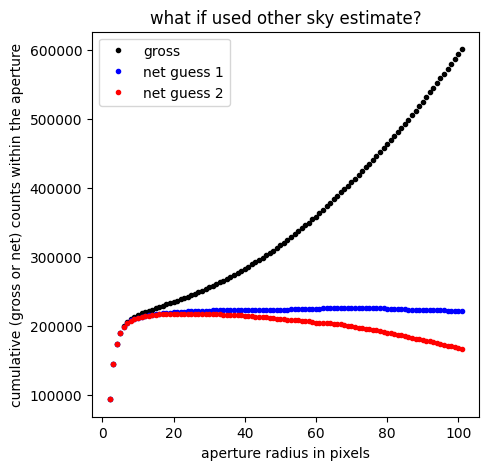

In [32]:
#what if we tried other values of the sky.
skyguess1 = skyestims[nsb-2]
skyguess2 = skyestims[2]
netguess1 = grosscnts - nelinap * skyguess1
netguess2 = grosscnts - nelinap * skyguess2


plt.figure( figsize = (5,5))
plt.plot(aps, grosscnts, '.', color='black', label='gross')
plt.plot(aps, netguess1, '.', color='blue', label='net guess 1')
plt.plot(aps, netguess2, '.', color='red', label='net guess 2')
plt.xlabel("aperture radius in pixels")
plt.ylabel("cumulative (gross or net) counts within the aperture")
plt.title("what if used other sky estimate?")
dm = plt.legend(loc='upper left')
#input(":")

#----------------------------------------------------------------------------
#end of program

In [ ]:
### Midterm!